# 🚦 Traffic Queue Prediction — Panel-Ready ML Notebook

### Project goal
Predict the **traffic queue length approximately 30 seconds into the future** from current traffic conditions, short-term trends, congestion, and signal state.

### What this notebook demonstrates
**Data → EDA → feature engineering → leakage-safe temporal split → model comparison → error analysis → Random Forest selection → saved model verification → deployment-style inference**

> **Panel note:** The notebook preserves the existing trained-model pipeline and reported results. The added text explains the reasoning and interpretation of each stage; it does not change the reported model metrics.


## 📦 GitHub-ready project structure

Place this notebook in `ml/notebooks/`. Keep `training_data.csv` and `test_data.csv` in `ml/data/`, and the trained model files in `ml/`. The notebook uses relative project paths so it is portable across machines.

> **Presentation note:** The executed outputs are intentionally preserved where they document the model-development results. Re-running the notebook is optional for the panel demo.


## 🧭 Notebook roadmap

1. **Load & understand the data**
2. **EDA:** quality, distributions, relationships, congestion cases
3. **Feature engineering:** create the 30-second target and short-term history features
4. **Temporal train/test split:** avoid future information leaking into training
5. **Model training:** Linear Regression, Random Forest, Gradient Boosting
6. **Evaluation & tuning:** error analysis, queue-level behavior, XGBoost comparison
7. **Final model:** Random Forest training, export, reload, verification
8. **Deployment-style demo:** give a traffic state → predict future queue → interpret trend


## 1. Libraries

In [2]:
# 1. DATA HANDLING
import pandas as pd
import numpy as np


# 2. VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns

# 3. PREPROCESSING
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler



# 4. MACHINE LEARNING MODELS
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 5. MODEL EVALUATION
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# 6. MODEL SAVING
import joblib

### 🔎 Inference — Why these libraries?
The imports cover the complete ML workflow: **Pandas/NumPy** for data handling, **Matplotlib/Seaborn** for EDA, **scikit-learn** for preprocessing/models/metrics, and **joblib** for saving the trained model.

**Panel takeaway:** this notebook is not only a model-training script; it covers the full path from raw traffic observations to a deployable prediction artifact.

#Mount Google Drive

In [ ]:
# Project paths
from pathlib import Path

# This notebook is stored in ml/notebooks/.
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / 'data'
MODEL_DIR = PROJECT_ROOT

print('Project root:', PROJECT_ROOT)
print('Data directory:', DATA_DIR)


### 🔎 Inference — Why Google Drive?
The original experiment was developed in Colab, so the datasets and exported model were stored in Google Drive.

**Panel takeaway:** this is an environment-specific storage step, not part of the prediction algorithm itself.

# Load dataset


In [ ]:
# Load scenario datasets from the repository
training_path = DATA_DIR / 'training_data.csv'
test_path = DATA_DIR / 'test_data.csv'

if not training_path.exists() or not test_path.exists():
    raise FileNotFoundError(
        'Expected training_data.csv and test_data.csv inside ml/data/. '
        'Add the datasets to that folder before running the notebook.'
    )

df_abc = pd.read_csv(training_path)
df_de = pd.read_csv(test_path)
df = pd.concat([df_abc, df_de], ignore_index=True)

print('Datasets loaded successfully! ✅')
print('A/B/C shape:', df_abc.shape)
print('D/E shape:', df_de.shape)
print('Combined shape:', df.shape)
print('\nScenario distribution:')
print(df['scenario'].value_counts().sort_index())


### 🔎 Inference — What does the dataset represent?
The combined dataset contains **2,800 observations across five scenarios (A–E)**, with **560 observations per scenario**.

Each observation captures a traffic state for an approach at a timestamp:
- vehicle count
- queue length
- average speed
- signal state (`is_green`)

**Why combine A–E?** The model should learn from multiple traffic regimes rather than one demand pattern.

**Panel takeaway:** the model is trained on both normal and heavier/changing traffic conditions.

In [5]:
df.head(20)


,scenario,timestamp,approach,vehicles,queue_length,average_speed,is_green
0,A,0,north,3,0,13.61,1
1,A,0,south,3,0,13.12,1
2,A,0,east,3,0,13.08,0
3,A,0,west,3,0,13.24,0
4,A,5,north,3,0,12.93,1
5,A,5,south,3,0,12.77,1
6,A,5,east,3,0,12.15,0
7,A,5,west,3,0,12.47,0
8,A,10,north,3,0,13.07,1
9,A,10,south,3,0,12.85,1


### 🔎 Inference — Why inspect the first rows?
A raw sample makes the dataset structure immediately visible before any transformation.

Notice that each timestamp appears for multiple approaches. That matters because traffic is **time-dependent and approach-dependent**, so later feature engineering must be grouped by both `scenario` and `approach`.

#EDA

In [6]:
# 1. DATASET OVERVIEW — A to E

print("Dataset Shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn Information:")
print(df.info())

print("\nNumerical Summary:")
display(df.describe())

print("\nScenario Distribution:")
print(df["scenario"].value_counts().sort_index())

print("\nApproach Distribution:")
print(df["approach"].value_counts().sort_index())

Dataset Shape: (2800, 7)

First 5 rows:


,scenario,timestamp,approach,vehicles,queue_length,average_speed,is_green
0,A,0,north,3,0,13.61,1
1,A,0,south,3,0,13.12,1
2,A,0,east,3,0,13.08,0
3,A,0,west,3,0,13.24,0
4,A,5,north,3,0,12.93,1



Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   scenario       2800 non-null   object 
 1   timestamp      2800 non-null   int64  
 2   approach       2800 non-null   object 
 3   vehicles       2800 non-null   int64  
 4   queue_length   2800 non-null   int64  
 5   average_speed  2800 non-null   float64
 6   is_green       2800 non-null   int64  
dtypes: float64(1), int64(4), object(2)
memory usage: 153.3+ KB
None

Numerical Summary:


,timestamp,vehicles,queue_length,average_speed,is_green
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,347.500000,4.420357,2.691429,7.793700,0.278571
std,202.103532,4.189689,3.242238,3.607209,0.448376
min,0.000000,0.000000,0.000000,0.010000,0.000000
25%,173.750000,1.000000,1.000000,4.800000,0.000000
50%,347.500000,3.000000,2.000000,7.615000,0.000000
75%,521.250000,6.000000,3.000000,9.515000,1.000000
max,695.000000,28.000000,26.000000,13.900000,1.000000



Scenario Distribution:
scenario
A    560
B    560
C    560
D    560
E    560
Name: count, dtype: int64

Approach Distribution:
approach
east     700
north    700
south    700
west     700
Name: count, dtype: int64


### 🔎 Inference — Dataset overview
The overview confirms the scale, columns, value ranges, and balanced scenario representation.

The target problem is naturally a **regression problem** because queue length is a numeric quantity rather than a class label.

**Panel takeaway:** before training, we establish exactly what one observation means and whether the dataset has enough variation for learning.

In [7]:
# 2. DATA QUALITY CHECK — A to E

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate timestamp + approach combinations:")
print(
    df.duplicated(
        subset=["scenario", "timestamp", "approach"]
    ).sum()
)

print("\nUnique values:")
print(df.nunique())

print("\nNegative values in traffic variables:")
print("Vehicles:", (df["vehicles"] < 0).sum())
print("Queue:", (df["queue_length"] < 0).sum())
print("Speed:", (df["average_speed"] < 0).sum())

Missing values:
scenario         0
timestamp        0
approach         0
vehicles         0
queue_length     0
average_speed    0
is_green         0
dtype: int64

Duplicate rows:
0

Duplicate timestamp + approach combinations:
0

Unique values:
scenario           5
timestamp        140
approach           4
vehicles          29
queue_length      26
average_speed    849
is_green           2
dtype: int64

Negative values in traffic variables:
Vehicles: 0
Queue: 0
Speed: 0


### 🔎 Inference — Data quality check
The checks look for missing values, duplicates, duplicate scenario–timestamp–approach records, and impossible negative traffic values.

The original run reported:
- no missing values
- no duplicate rows
- no duplicate scenario–timestamp–approach observations
- no negative values in vehicles, queue, or speed

**Why this matters:** bad records can create artificial patterns and distort the learned relationship between traffic state and future queue.

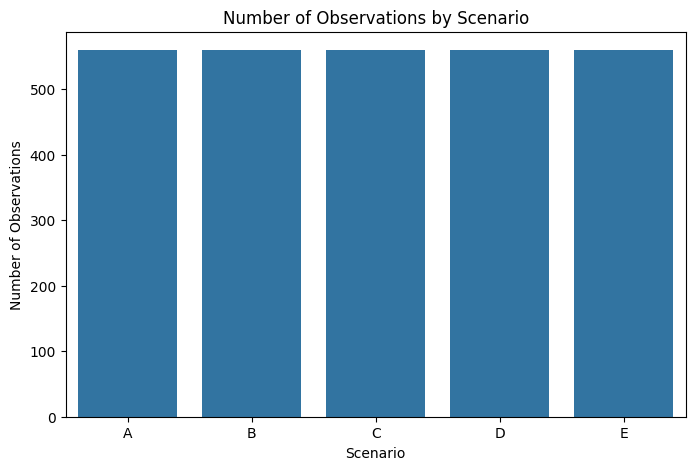

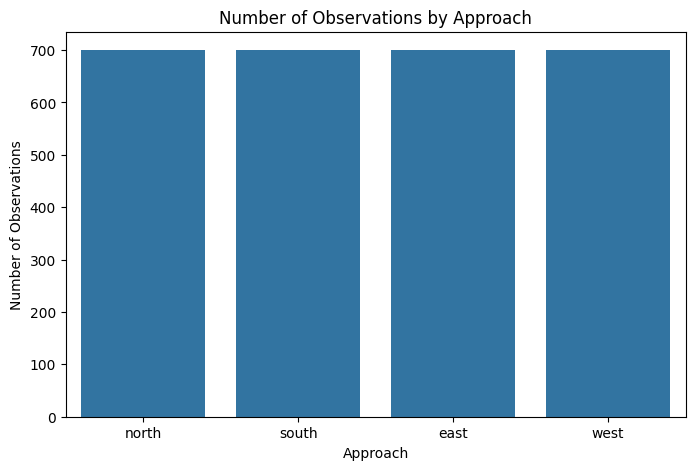

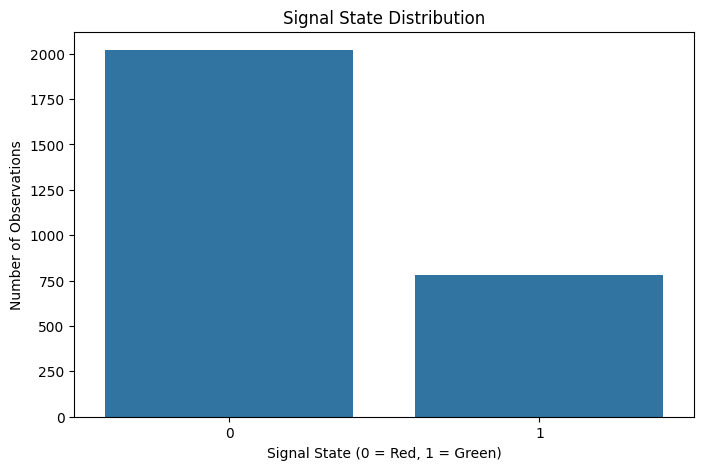

Scenario × Approach distribution:


approach,east,north,south,west
scenario,,,,
A,140,140,140,140
B,140,140,140,140
C,140,140,140,140
D,140,140,140,140
E,140,140,140,140


Scenario × Signal State distribution:


is_green,0,1
scenario,,
A,404,156
B,404,156
C,404,156
D,404,156
E,404,156


In [8]:
# ============================================================
# 3. CATEGORICAL VARIABLE ANALYSIS — A to E
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# Scenario distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="scenario")
plt.title("Number of Observations by Scenario")
plt.xlabel("Scenario")
plt.ylabel("Number of Observations")
plt.show()


# ------------------------------------------------------------
# Approach distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="approach")
plt.title("Number of Observations by Approach")
plt.xlabel("Approach")
plt.ylabel("Number of Observations")
plt.show()


# ------------------------------------------------------------
# Signal state distribution
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="is_green")
plt.title("Signal State Distribution")
plt.xlabel("Signal State (0 = Red, 1 = Green)")
plt.ylabel("Number of Observations")
plt.show()


# ------------------------------------------------------------
# Scenario × Approach
# ------------------------------------------------------------

scenario_approach = pd.crosstab(
    df["scenario"],
    df["approach"]
)

print("Scenario × Approach distribution:")
display(scenario_approach)


# ------------------------------------------------------------
# Scenario × Signal State
# ------------------------------------------------------------

scenario_signal = pd.crosstab(
    df["scenario"],
    df["is_green"]
)

print("Scenario × Signal State distribution:")
display(scenario_signal)


### 🔎 Inference — Categorical variables
Scenario, approach, and signal state are not just labels—they describe **different traffic contexts**.

The distributions are checked so we know the model is not accidentally learning from a highly unbalanced subset such as one approach or one scenario dominating the dataset.

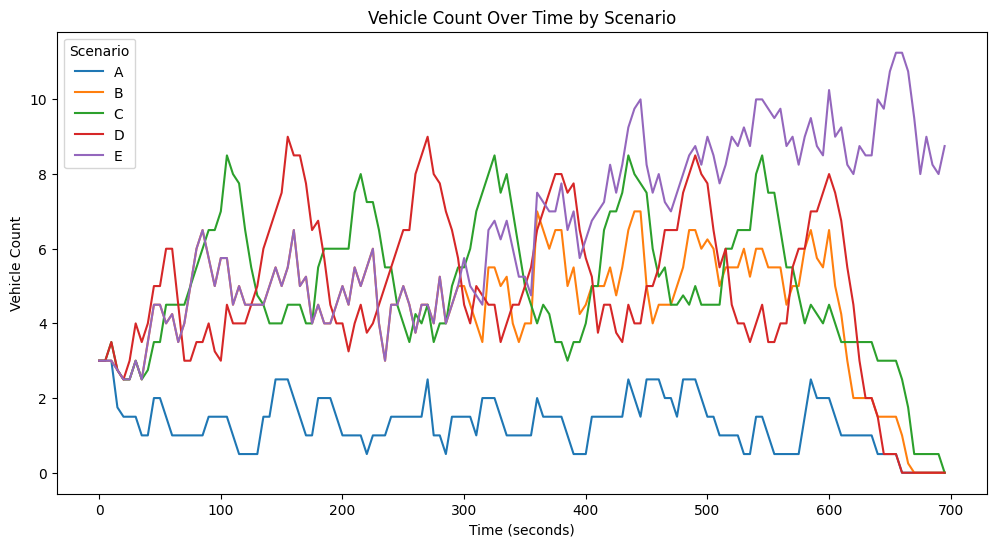

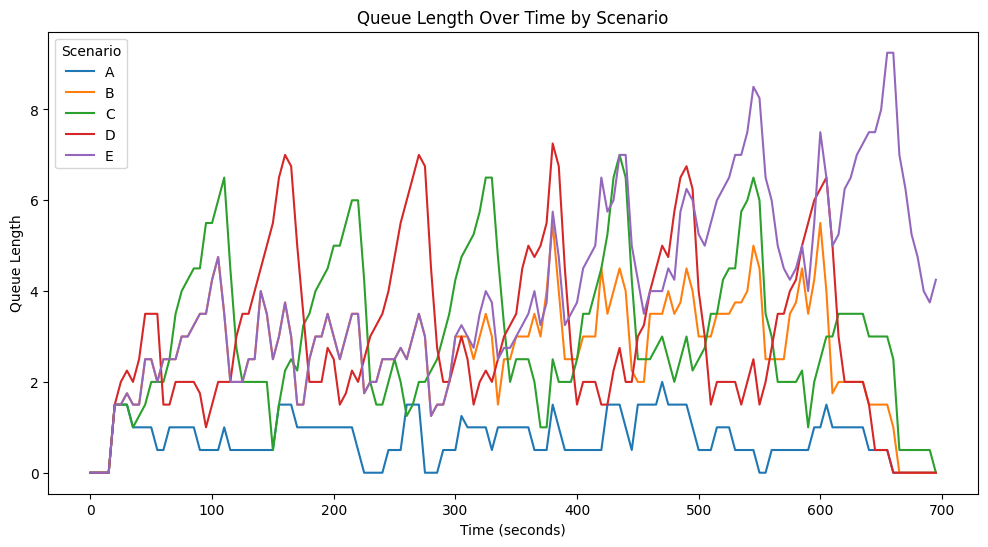

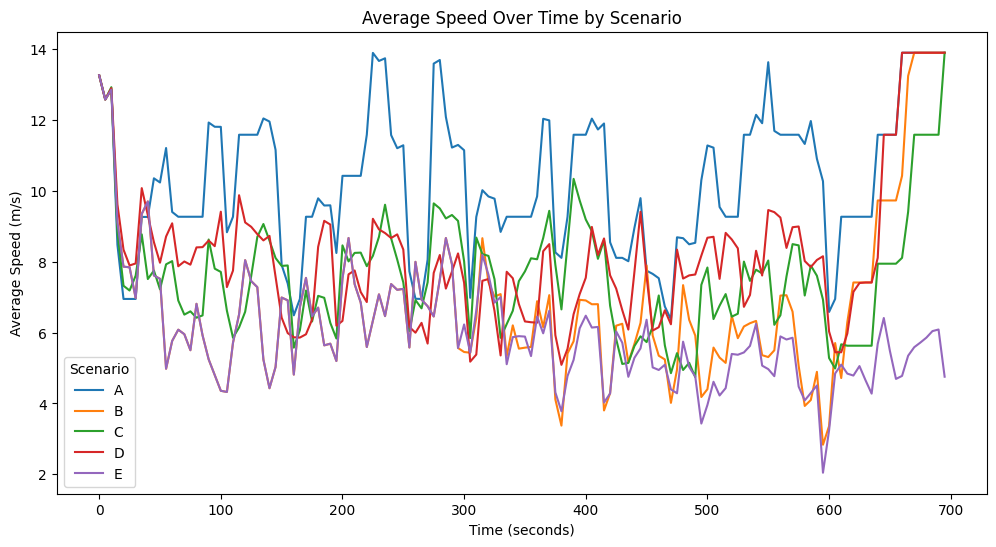

In [9]:
# ============================================================
# 4. TRAFFIC VARIABLES OVER TIME — A to E
# ============================================================



# Vehicle count over time

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="timestamp",
    y="vehicles",
    hue="scenario",
    errorbar=None
)

plt.title("Vehicle Count Over Time by Scenario")
plt.xlabel("Time (seconds)")
plt.ylabel("Vehicle Count")
plt.legend(title="Scenario")
plt.show()


# ------------------------------------------------------------
# Queue length over time
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="timestamp",
    y="queue_length",
    hue="scenario",
    errorbar=None
)

plt.title("Queue Length Over Time by Scenario")
plt.xlabel("Time (seconds)")
plt.ylabel("Queue Length")
plt.legend(title="Scenario")
plt.show()


# ------------------------------------------------------------
# Average speed over time
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x="timestamp",
    y="average_speed",
    hue="scenario",
    errorbar=None
)

plt.title("Average Speed Over Time by Scenario")
plt.xlabel("Time (seconds)")
plt.ylabel("Average Speed (m/s)")
plt.legend(title="Scenario")
plt.show()

### 🔎 Inference — Traffic variables over time
These time-series plots answer the key question:

> **Does traffic state actually change over time and across scenarios?**

We expect vehicle counts and queues to vary with traffic demand and signal operation, while speed responds to congestion.

**Panel takeaway:** the prediction problem has a temporal pattern, which is why a temporal split is more appropriate than randomly shuffling observations.

In [10]:
#Vehicle Count Over Time

#Inference: Scenario A shows the lowest vehicle count, while Scenario C shows the highest due to its heavier traffic demand.
#Vehicle counts vary over time, indicating dynamic traffic conditions influenced by vehicle arrivals and signal operation.

### 🔎 Inference — Vehicle-count behavior
The original analysis identifies Scenario A as the lowest-demand case and Scenario C as the highest-demand case.

The important modeling insight is not the scenario label itself; it is that **traffic demand is dynamic**, so the model benefits from current state plus recent history.

Correlation Matrix:


,vehicles,queue_length,average_speed,is_green
vehicles,1.000,0.921,-0.751,0.017
queue_length,0.921,1.000,-0.770,-0.067
average_speed,-0.751,-0.770,1.000,0.083
is_green,0.017,-0.067,0.083,1.000


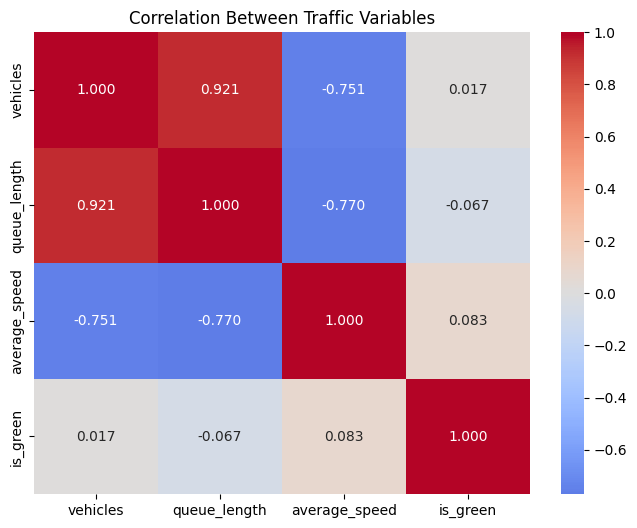

In [11]:
# ============================================================
# 5. CORRELATION ANALYSIS — A to E
# ============================================================

# Select numerical traffic variables
correlation_columns = [
    "vehicles",
    "queue_length",
    "average_speed",
    "is_green"
]

correlation_matrix = df[correlation_columns].corr()

print("Correlation Matrix:")
display(correlation_matrix.round(3))


# ------------------------------------------------------------
# Correlation heatmap
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Traffic Variables")
plt.show()

### 🔎 Inference — Correlation
Correlation is used here as an exploratory tool, not as proof of causation.

The original analysis found:
- vehicle count and queue length move positively together
- vehicle count and speed move negatively
- queue length and speed move negatively

**Why this matters:** these relationships support the intuition behind using vehicles, queue, and speed together to describe traffic state.

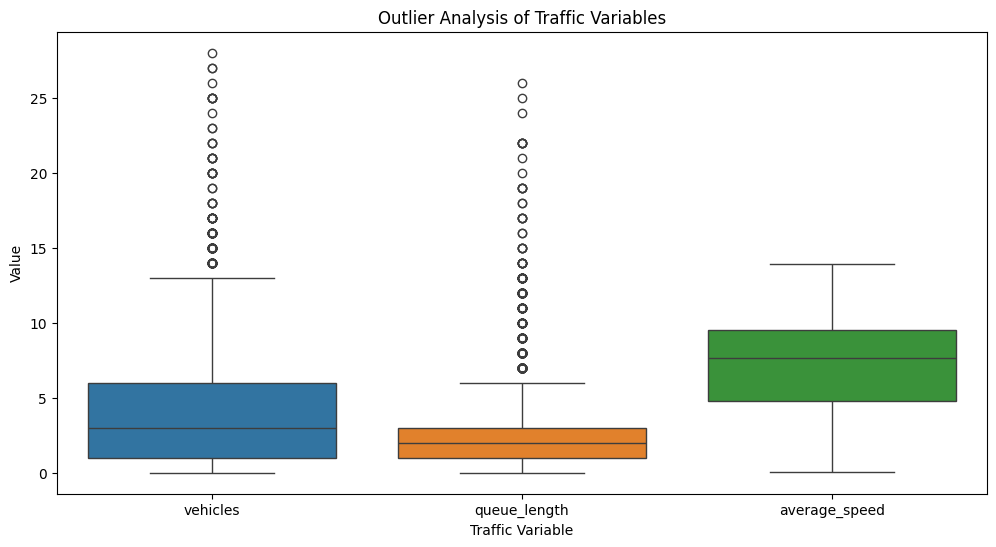

Observations with queue length > 10:
Count: 113

Scenario distribution:
scenario
C    35
D    40
E    38
Name: count, dtype: int64

Highest queue observations:


,scenario,timestamp,approach,vehicles,queue_length,average_speed
2768,E,660,north,28,26,0.65
2764,E,655,north,27,25,0.81
2760,E,650,north,26,24,1.39
2756,E,645,north,25,22,1.39
2680,E,550,north,25,22,1.22
2772,E,665,north,27,22,1.18
2676,E,545,north,25,22,1.09
2752,E,640,north,24,22,1.52
2672,E,540,north,25,21,1.73
2748,E,635,north,22,20,1.13


In [12]:
# ============================================================
# 6. OUTLIER ANALYSIS — A to E
# ============================================================

numerical_columns = [
    "vehicles",
    "queue_length",
    "average_speed"
]

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df[numerical_columns]
)

plt.title("Outlier Analysis of Traffic Variables")
plt.xlabel("Traffic Variable")
plt.ylabel("Value")
plt.show()


# ------------------------------------------------------------
# Identify high queue observations
# ------------------------------------------------------------

high_queue = df[df["queue_length"] > 10]

print("Observations with queue length > 10:")
print("Count:", len(high_queue))

print("\nScenario distribution:")
print(
    high_queue["scenario"]
    .value_counts()
    .sort_index()
)

print("\nHighest queue observations:")
display(
    high_queue[
        [
            "scenario",
            "timestamp",
            "approach",
            "vehicles",
            "queue_length",
            "average_speed"
        ]
    ]
    .sort_values("queue_length", ascending=False)
    .head(10)
)

### 🔎 Inference — Outliers
High queue values are investigated instead of automatically deleted.

In traffic, a large queue can be a **real event**, especially in heavy-demand scenarios C, D, and E. Removing these observations would make the model look cleaner while making it less representative of the congestion conditions we actually want it to handle.

**Panel takeaway:** an unusual traffic state is not necessarily a bad data point.

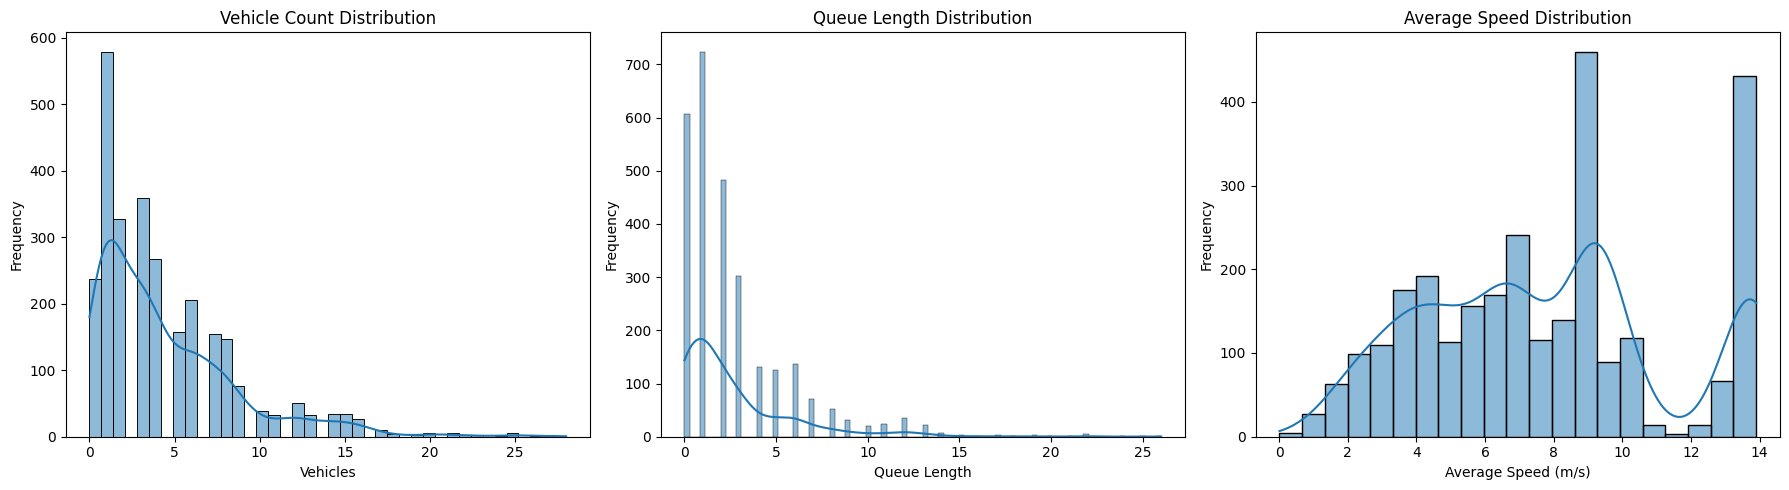

In [13]:
# ============================================================
# 7. DISTRIBUTION ANALYSIS — A to E
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Vehicle count
sns.histplot(
    data=df,
    x="vehicles",
    kde=True,
    ax=axes[0]
)
axes[0].set_title("Vehicle Count Distribution")
axes[0].set_xlabel("Vehicles")
axes[0].set_ylabel("Frequency")

# Queue length
sns.histplot(
    data=df,
    x="queue_length",
    kde=True,
    ax=axes[1]
)
axes[1].set_title("Queue Length Distribution")
axes[1].set_xlabel("Queue Length")
axes[1].set_ylabel("Frequency")

# Average speed
sns.histplot(
    data=df,
    x="average_speed",
    kde=True,
    ax=axes[2]
)
axes[2].set_title("Average Speed Distribution")
axes[2].set_xlabel("Average Speed (m/s)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()
plt.show()


### 🔎 Inference — Distributions
The distributions show how often different traffic conditions occur.

The original notebook notes that vehicle count and queue length are right-skewed, meaning heavy-congestion cases are less frequent than normal conditions.

**Modeling implication:** performance should be checked not only on average, but also on high-queue cases where prediction errors can matter more operationally.

In [14]:
print("===== EDA SUMMARY =====")

print("Dataset shape:", df.shape)
print("Scenarios:", df["scenario"].unique())
print("Approaches:", df["approach"].unique())

print("\nKey observations:")
print("1. The dataset contains 2,800 observations across five traffic scenarios (A–E).")
print("2. Each scenario contains equal observations, providing balanced scenario representation.")
print("3. No missing values, duplicate rows, or duplicate scenario-timestamp-approach observations were found.")
print("4. Vehicle count and queue length are strongly positively correlated.")
print("5. Vehicle count and average speed show a strong negative relationship.")
print("6. Queue length and average speed also show a strong negative relationship.")
print("7. Vehicle count and queue length distributions are right-skewed, with fewer observations representing heavy congestion.")
print("8. High queue-length observations are concentrated mainly in the heavy-demand scenarios C, D, and E.")
print("9. These high-congestion observations are retained because they represent genuine traffic conditions.")
print("10. The dataset contains sufficient variation in traffic demand and congestion for short-term queue prediction.")

===== EDA SUMMARY =====
Dataset shape: (2800, 7)
Scenarios: ['A' 'B' 'C' 'D' 'E']
Approaches: ['north' 'south' 'east' 'west']

Key observations:
1. The dataset contains 2,800 observations across five traffic scenarios (A–E).
2. Each scenario contains equal observations, providing balanced scenario representation.
3. No missing values, duplicate rows, or duplicate scenario-timestamp-approach observations were found.
4. Vehicle count and queue length are strongly positively correlated.
5. Vehicle count and average speed show a strong negative relationship.
6. Queue length and average speed also show a strong negative relationship.
7. Vehicle count and queue length distributions are right-skewed, with fewer observations representing heavy congestion.
8. High queue-length observations are concentrated mainly in the heavy-demand scenarios C, D, and E.
9. These high-congestion observations are retained because they represent genuine traffic conditions.
10. The dataset contains sufficient var

### 🔎 Inference — EDA conclusion
The EDA establishes three important facts:
1. the dataset is balanced across scenarios A–E,
2. traffic variables have meaningful relationships,
3. heavy-congestion cases exist and are intentionally retained.

That gives us a defensible basis for moving from exploration to predictive feature engineering.

# 2. Feature Engineering


In [15]:
# Sort traffic observations chronologically within each scenario and approach

df_fe = df.sort_values(
    by=["scenario", "approach", "timestamp"]
).reset_index(drop=True)

print("Feature engineering dataset shape:", df_fe.shape)

display(
    df_fe[
        ["scenario", "approach", "timestamp",
         "vehicles", "queue_length", "average_speed", "is_green"]
    ].head(20)
)

Feature engineering dataset shape: (2800, 7)


,scenario,approach,timestamp,vehicles,queue_length,average_speed,is_green
0,A,east,0,3,0,13.08,0
1,A,east,5,3,0,12.15,0
2,A,east,10,3,0,12.93,0
3,A,east,15,2,0,7.34,0
4,A,east,20,2,2,4.63,0
5,A,east,25,2,2,4.63,0
6,A,east,30,2,2,4.63,0
7,A,east,35,2,2,4.63,0
8,A,east,40,2,2,4.63,0
9,A,east,45,3,2,6.92,0


### 🔎 Inference — Why sort by scenario, approach, and timestamp?
Temporal features such as trends and rolling averages only make sense when observations are in chronological order.

Grouping by **scenario + approach** prevents a north-side observation from accidentally using the previous timestamp belonging to another approach.

In [62]:
# Prediction horizon
PREDICTION_HORIZON = 6   # 6 × 5 seconds = 30 seconds

# Create the future queue-length target
df_fe["target_queue_30s"] = (
    df_fe
    .groupby(["scenario", "approach"])["queue_length"]
    .shift(-PREDICTION_HORIZON)
)

display(
    df_fe[
        ["scenario", "approach", "timestamp",
         "queue_length", "target_queue_30s"]
    ].head(15)
)

,scenario,approach,timestamp,queue_length,target_queue_30s
0,A,east,0,0,2.0
1,A,east,5,0,2.0
2,A,east,10,0,2.0
3,A,east,15,0,2.0
4,A,east,20,2,2.0
5,A,east,25,2,1.0
6,A,east,30,2,1.0
7,A,east,35,2,1.0
8,A,east,40,2,1.0
9,A,east,45,2,1.0


### 🔎 Inference — Why predict 30 seconds ahead?
The data is sampled every **5 seconds**. Shifting the queue by 6 observations therefore creates:

**6 × 5 s = 30 s future queue**

This converts the problem from “describe current traffic” into a genuinely predictive task.

**Panel takeaway:** the signal controller can use a near-future queue estimate instead of reacting only after congestion has already formed.

In [63]:
LOOKBACK_WINDOW = 4   # 4 × 5 seconds = 20 seconds

group_cols = ["scenario", "approach"]

# Previous observations
df_fe["prev_vehicles"] = (
    df_fe.groupby(group_cols)["vehicles"].shift(1)
)

df_fe["prev_queue"] = (
    df_fe.groupby(group_cols)["queue_length"].shift(1)
)

df_fe["prev_speed"] = (
    df_fe.groupby(group_cols)["average_speed"].shift(1)
)

# Short-term trends
df_fe["count_trend"] = (
    df_fe["vehicles"] - df_fe["prev_vehicles"]
)

df_fe["queue_trend"] = (
    df_fe["queue_length"] - df_fe["prev_queue"]
)

df_fe["speed_trend"] = (
    df_fe["average_speed"] - df_fe["prev_speed"]
)

# Rolling averages over the previous 4 readings
df_fe["avg_count_20s"] = (
    df_fe.groupby(group_cols)["vehicles"]
    .transform(lambda x: x.shift(1).rolling(LOOKBACK_WINDOW).mean())
)

df_fe["avg_queue_20s"] = (
    df_fe.groupby(group_cols)["queue_length"]
    .transform(lambda x: x.shift(1).rolling(LOOKBACK_WINDOW).mean())
)

df_fe["avg_speed_20s"] = (
    df_fe.groupby(group_cols)["average_speed"]
    .transform(lambda x: x.shift(1).rolling(LOOKBACK_WINDOW).mean())
)

display(
    df_fe[
        ["scenario", "approach", "timestamp",
         "vehicles", "queue_length", "average_speed",
         "count_trend", "queue_trend", "speed_trend",
         "avg_count_20s", "avg_queue_20s", "avg_speed_20s"]
    ].head(15)
)

,scenario,approach,timestamp,vehicles,queue_length,average_speed,count_trend,queue_trend,speed_trend,avg_count_20s,avg_queue_20s,avg_speed_20s
0,A,east,0,3,0,13.08,NaN,NaN,NaN,NaN,NaN,NaN
1,A,east,5,3,0,12.15,0.0,0.0,-0.93,NaN,NaN,NaN
2,A,east,10,3,0,12.93,0.0,0.0,0.78,NaN,NaN,NaN
3,A,east,15,2,0,7.34,-1.0,0.0,-5.59,NaN,NaN,NaN
4,A,east,20,2,2,4.63,0.0,2.0,-2.71,2.75,0.00,11.3750
5,A,east,25,2,2,4.63,0.0,0.0,0.00,2.50,0.50,9.2625
6,A,east,30,2,2,4.63,0.0,0.0,0.00,2.25,1.00,7.3825
7,A,east,35,2,2,4.63,0.0,0.0,0.00,2.00,1.50,5.3075
8,A,east,40,2,2,4.63,0.0,0.0,0.00,2.00,2.00,4.6300
9,A,east,45,3,2,6.92,1.0,0.0,2.29,2.00,2.00,4.6300


### 🔎 Inference — Why add trends and rolling averages?
A single snapshot can be misleading.

We therefore add:
- **trend features**: whether count/queue/speed is rising or falling
- **20-second rolling averages**: the recent traffic baseline

The rolling averages are calculated from **previous observations (`shift(1)`)**, excluding the current value. This is important because it avoids letting the current observation leak into a “history” feature.

**Panel takeaway:** the model sees both **current state + recent direction + recent baseline**.

In [64]:
# Maximum/reference values from the SUMO scenarios
MAX_QUEUE = 10
MAX_VEHICLES = 10
MAX_SPEED = 13.9

# Normalize each traffic component
queue_norm = (df_fe["queue_length"] / MAX_QUEUE).clip(0, 1)
vehicle_norm = (df_fe["vehicles"] / MAX_VEHICLES).clip(0, 1)

speed_norm = (
    1 - (df_fe["average_speed"] / MAX_SPEED)
).clip(0, 1)

# Weighted congestion score
df_fe["congestion_score"] = (
    0.4 * queue_norm +
    0.3 * vehicle_norm +
    0.3 * speed_norm
)

display(
    df_fe[
        ["scenario", "approach", "timestamp",
         "vehicles", "queue_length", "average_speed",
         "congestion_score"]
    ].head(15)
)

,scenario,approach,timestamp,vehicles,queue_length,average_speed,congestion_score
0,A,east,0,3,0,13.08,0.107698
1,A,east,5,3,0,12.15,0.127770
2,A,east,10,3,0,12.93,0.110935
3,A,east,15,2,0,7.34,0.201583
4,A,east,20,2,2,4.63,0.340072
5,A,east,25,2,2,4.63,0.340072
6,A,east,30,2,2,4.63,0.340072
7,A,east,35,2,2,4.63,0.340072
8,A,east,40,2,2,4.63,0.340072
9,A,east,45,3,2,6.92,0.320647


### 🔎 Inference — Why create a congestion score?
Traffic condition is multidimensional. A junction can have many vehicles, a long queue, or low speed—or a combination of all three.

The engineered score compresses these signals into one traffic-state indicator that can be supplied to the model.

**Important:** the normalization constants are based on the project’s SUMO scenario reference ranges, so this score is project-specific rather than a universal traffic standard.

In [ ]:
# Feature-engineering consistency check

required_source_columns = [
    "scenario", "approach", "timestamp",
    "vehicles", "queue_length", "average_speed", "is_green"
]

missing_columns = [
    col for col in required_source_columns
    if col not in df_fe.columns
]

print("Required source columns present:", not missing_columns)

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("Feature-engineering input structure is consistent.")


### 🔎 Inference — Feature-engineering consistency check
This stage verifies that the feature-engineering table contains the raw traffic variables needed for the final feature set.

The previous notebook contained a redundant block referencing `current_count`, `current_queue`, and `current_speed`, even though the active pipeline uses `vehicles`, `queue_length`, and `average_speed`. That older block was removed to prevent confusion and execution errors.

In [65]:
# Final feature columns
feature_columns = [
    "vehicles",
    "queue_length",
    "average_speed",
    "count_trend",
    "queue_trend",
    "speed_trend",
    "avg_count_20s",
    "avg_queue_20s",
    "avg_speed_20s",
    "congestion_score",
    "is_green"
]

target_column = "target_queue_30s"

# Keep only rows with all required features and target
df_model = df_fe.dropna(
    subset=feature_columns + [target_column]
).copy()

print("Original rows:", len(df_fe))
print("Model-ready rows:", len(df_model))
print("Rows removed:", len(df_fe) - len(df_model))

print("\nFeatures:")
print(feature_columns)

print("\nTarget:")
print(target_column)

display(
    df_model[
        ["scenario", "approach", "timestamp"] +
        feature_columns +
        [target_column]
    ].head(10)
)

Original rows: 2800
Model-ready rows: 2600
Rows removed: 200

Features:
['vehicles', 'queue_length', 'average_speed', 'count_trend', 'queue_trend', 'speed_trend', 'avg_count_20s', 'avg_queue_20s', 'avg_speed_20s', 'congestion_score', 'is_green']

Target:
target_queue_30s


,scenario,approach,timestamp,vehicles,queue_length,average_speed,count_trend,queue_trend,speed_trend,avg_count_20s,avg_queue_20s,avg_speed_20s,congestion_score,is_green,target_queue_30s
4,A,east,20,2,2,4.63,0.0,2.0,-2.71,2.75,0.00,11.3750,0.340072,0,2.0
5,A,east,25,2,2,4.63,0.0,0.0,0.00,2.50,0.50,9.2625,0.340072,0,1.0
6,A,east,30,2,2,4.63,0.0,0.0,0.00,2.25,1.00,7.3825,0.340072,0,1.0
7,A,east,35,2,2,4.63,0.0,0.0,0.00,2.00,1.50,5.3075,0.340072,0,1.0
8,A,east,40,2,2,4.63,0.0,0.0,0.00,2.00,2.00,4.6300,0.340072,0,1.0
9,A,east,45,3,2,6.92,1.0,0.0,2.29,2.00,2.00,4.6300,0.320647,0,1.0
10,A,east,50,3,2,6.78,0.0,0.0,-0.14,2.25,2.00,5.2025,0.323669,0,1.0
11,A,east,55,2,1,9.00,-1.0,-1.0,2.22,2.50,2.00,5.7400,0.205755,1,1.0
12,A,east,60,1,1,9.27,-1.0,0.0,0.27,2.50,1.75,6.8325,0.169928,1,0.0
13,A,east,65,1,1,9.27,0.0,0.0,0.00,2.25,1.50,7.9925,0.169928,1,0.0


### 🔎 Inference — Final feature set
The final model uses **11 features**:

`vehicles, queue_length, average_speed, count_trend, queue_trend, speed_trend, avg_count_20s, avg_queue_20s, avg_speed_20s, congestion_score, is_green`

The target is `target_queue_30s`.

Rows with incomplete history are dropped because the model cannot calculate the required trend/rolling features for them.

**Panel takeaway:** the model combines instantaneous traffic, temporal behavior, congestion context, and signal state.

In [66]:
# Temporal split point
TRAIN_CUTOFF = 560

# Sort again for safety
df_model = df_model.sort_values(
    by=["scenario", "approach", "timestamp"]
).reset_index(drop=True)

# Training data:
# Current observation is before 560s AND its 30s target is also before 560s
train_df = df_model[
    (df_model["timestamp"] < TRAIN_CUTOFF) &
    (df_model["timestamp"] + 30 < TRAIN_CUTOFF)
].copy()

# Test data:
# Current observation is at/after 560s
test_df = df_model[
    df_model["timestamp"] >= TRAIN_CUTOFF
].copy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print("\nTraining timestamp range:")
print(train_df["timestamp"].min(), "to", train_df["timestamp"].max())

print("\nTesting timestamp range:")
print(test_df["timestamp"].min(), "to", test_df["timestamp"].max())

print("\nTraining rows by scenario:")
print(train_df["scenario"].value_counts().sort_index())

print("\nTesting rows by scenario:")
print(test_df["scenario"].value_counts().sort_index())

Training rows: 2040
Testing rows: 440

Training timestamp range:
20 to 525

Testing timestamp range:
560 to 665

Training rows by scenario:
scenario
A    408
B    408
C    408
D    408
E    408
Name: count, dtype: int64

Testing rows by scenario:
scenario
A    88
B    88
C    88
D    88
E    88
Name: count, dtype: int64


### 🔎 Inference — Why a temporal split instead of random train_test_split?
Random shuffling can put future observations into the training set while earlier observations land in the test set. For a time-dependent prediction problem, that can make performance look better than it really is.

This notebook instead trains on earlier timestamps and evaluates on later timestamps.

The additional condition that the training target must also remain before the cutoff prevents a training row from using a future target that crosses into the held-out period.

**Panel takeaway:** this is a leakage-conscious evaluation design.

# 3. Train–Test Split


In [67]:
# Create feature matrices and target vectors

X_train = train_df[feature_columns].copy()
y_train = train_df[target_column].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df[target_column].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

print("\nFeature columns:")
print(X_train.columns.tolist())

print("\nTraining target statistics:")
print(y_train.describe())

print("\nTesting target statistics:")
print(y_test.describe())

X_train: (2040, 11)
y_train: (2040,)
X_test : (440, 11)
y_test : (440,)

Feature columns:
['vehicles', 'queue_length', 'average_speed', 'count_trend', 'queue_trend', 'speed_trend', 'avg_count_20s', 'avg_queue_20s', 'avg_speed_20s', 'congestion_score', 'is_green']

Training target statistics:
count    2040.000000
mean        2.884314
std         3.143042
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        22.000000
Name: target_queue_30s, dtype: float64

Testing target statistics:
count    440.000000
mean       2.502273
std        4.070002
min        0.000000
25%        0.000000
50%        1.000000
75%        3.000000
max       26.000000
Name: target_queue_30s, dtype: float64


### 🔎 Inference — Train/test matrices
Here we separate predictors `X` from the future queue target `y`.

The test set is kept untouched until model evaluation. That is important because model selection should be based on performance on data the model did not train on.

# 4. Preprocessing

## Feature Scaling

In [69]:
# ==========================================
# FEATURE SCALING
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape :", X_test_scaled.shape)

print("\nTraining feature means after scaling:")
print(X_train_scaled.mean(axis=0).round(4))

print("\nTraining feature standard deviations after scaling:")
print(X_train_scaled.std(axis=0).round(4))

Scaled training shape: (2040, 11)
Scaled testing shape : (440, 11)

Training feature means after scaling:
[ 0.  0. -0.  0. -0.  0.  0.  0.  0.  0. -0.]

Training feature standard deviations after scaling:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 🔎 Inference — Why scale the features?
Standardization is used for **Linear Regression** so numerical features are placed on comparable scales.

For the tree-based models—Random Forest, Gradient Boosting, and XGBoost—feature scaling is not required for the same reason, so their original unscaled inputs are retained.

**Panel takeaway:** preprocessing is chosen to match the model family rather than applying one transformation blindly to every algorithm.

# 5. Model Training

## Linear Regression

In [70]:
# ==========================================
# MODEL 1 — LINEAR REGRESSION
# ==========================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Create model
lr_model = LinearRegression()

# Train
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluate
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print(f"MAE  : {lr_mae:.4f}")
print(f"RMSE : {lr_rmse:.4f}")
print(f"R²   : {lr_r2:.4f}")

Linear Regression Results
-------------------------
MAE  : 1.5469
RMSE : 2.7201
R²   : 0.5523


### 🔎 Inference — Linear Regression baseline
Linear Regression is the simplest benchmark.

It asks whether future queue length can be approximated mainly as a weighted linear combination of the traffic features.

If nonlinear tree models improve substantially over this baseline, that suggests the traffic-to-queue relationship is not adequately captured by a single straight-line relationship.

## Random Forest


In [71]:
# ==========================================
# MODEL 2 — RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("--------------------")
print(f"MAE  : {rf_mae:.4f}")
print(f"RMSE : {rf_rmse:.4f}")
print(f"R²   : {rf_r2:.4f}")

Random Forest Results
--------------------
MAE  : 1.2380
RMSE : 1.9387
R²   : 0.7726


### 🔎 Inference — Random Forest
Random Forest combines many decision trees and can model nonlinear feature interactions.

For this project, that is useful because queue behavior can change depending on combinations such as:
**vehicle count + recent trend + speed + signal state**.

Reported test performance:
- **MAE = 1.2380**
- **RMSE = 1.9387**
- **R² = 0.7726**

In [72]:
# ==========================================
# MODEL 3 — GRADIENT BOOSTING
# ==========================================

from sklearn.ensemble import GradientBoostingRegressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# Train
gb_model.fit(X_train, y_train)

# Predict
y_pred_gb = gb_model.predict(X_test)

# Evaluate
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("-------------------------")
print(f"MAE  : {gb_mae:.4f}")
print(f"RMSE : {gb_rmse:.4f}")
print(f"R²   : {gb_r2:.4f}")

Gradient Boosting Results
-------------------------
MAE  : 1.3038
RMSE : 2.2236
R²   : 0.7008


### 🔎 Inference — Gradient Boosting
Gradient Boosting is another nonlinear tree-based approach, but it builds trees sequentially so each new tree focuses on correcting earlier errors.

Reported test performance:
- **MAE = 1.3038**
- **RMSE = 2.2236**
- **R² = 0.7008**

The results show that this configuration captured less of the held-out variance than the Random Forest configuration used here.

### 🔎 Inference — Early baseline conclusion

Random Forest already outperformed the two baseline models in the reported held-out evaluation, so the remaining analysis focuses on **understanding, tuning, stress-testing, and deployment verification** rather than assuming the first result is automatically sufficient.

## 6. Model Evaluation

In [75]:
# ==========================================
# RANDOM FOREST — FEATURE IMPORTANCE
# ==========================================

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Random Forest Feature Importance:")
print(feature_importance)

Random Forest Feature Importance:
vehicles            0.383075
avg_speed_20s       0.173513
congestion_score    0.107778
is_green            0.101810
avg_count_20s       0.094076
avg_queue_20s       0.041408
average_speed       0.040803
speed_trend         0.028347
queue_trend         0.012810
count_trend         0.008462
queue_length        0.007917
dtype: float64


### 🔎 Inference — Feature importance
Random Forest feature importance tells us which inputs contributed most to the ensemble's predictions.

In this run, **vehicle count** was the largest contributor (~0.383), followed by the **20-second average speed** (~0.174), then congestion score, signal state, and 20-second average count.

**Important:** feature importance indicates predictive contribution; it does **not** prove that a feature causes the queue to change.

In [76]:
# ==========================================
# BASELINE MODEL COMPARISON
# ==========================================

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        lr_r2,
        rf_r2,
        gb_r2
    ]
})

print(results.round(4))

               Model     MAE    RMSE      R2
0  Linear Regression  1.5469  2.7201  0.5523
1      Random Forest  1.2380  1.9387  0.7726
2  Gradient Boosting  1.3038  2.2236  0.7008


### 🔎 Inference — Baseline comparison
The baseline results are:

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Linear Regression | 1.5469 | 2.7201 | 0.5523 |
| Random Forest | 1.2380 | 1.9387 | 0.7726 |
| Gradient Boosting | 1.3038 | 2.2236 | 0.7008 |

For all three metrics, **higher R² is better; lower MAE/RMSE are better**.

At this stage, Random Forest gives the strongest combination of the evaluated baseline metrics.

# 7. Hyperparameter Tuning

In [77]:
# ==========================================
# RANDOM FOREST — HYPERPARAMETER TUNING
# ==========================================

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Validation split inside the training data
tscv = TimeSeriesSplit(n_splits=3)

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_tuned = GridSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

rf_tuned.fit(X_train, y_train)

print("\nBest Parameters:")
print(rf_tuned.best_params_)

print("\nBest Validation MAE:")
print(-rf_tuned.best_score_)


Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Validation MAE:
1.0219869764868739


### 🔎 Inference — Why tune the Random Forest?
Hyperparameter tuning tests whether a different tree count or tree complexity improves generalization.

`TimeSeriesSplit` is used inside the training data so the validation folds still respect temporal order.

The best validation configuration used **200 trees** with the other reported settings unchanged.

**Crucial point:** validation performance is not the final test performance; the untouched test set is evaluated separately in the next cell.

In [78]:
best_rf = rf_tuned.best_estimator_

# Predict on untouched test set
y_pred_tuned = best_rf.predict(X_test)

# Evaluation metrics
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest Results")
print("---------------------------")
print(f"MAE  : {tuned_mae:.4f}")
print(f"RMSE : {tuned_rmse:.4f}")
print(f"R²   : {tuned_r2:.4f}")

Tuned Random Forest Results
---------------------------
MAE  : 1.2490
RMSE : 1.9487
R²   : 0.7702


### 🔎 Inference — Tuned model vs original model
The tuned Random Forest achieved:

- **MAE = 1.2490**
- **RMSE = 1.9487**
- **R² = 0.7702**

That is slightly worse on this held-out test set than the original 100-tree Random Forest.

**Why this matters:** tuning does not automatically make a model better. The simpler 100-tree configuration remains preferable for this project because its held-out performance is at least as strong here and it is the model already aligned with deployment.

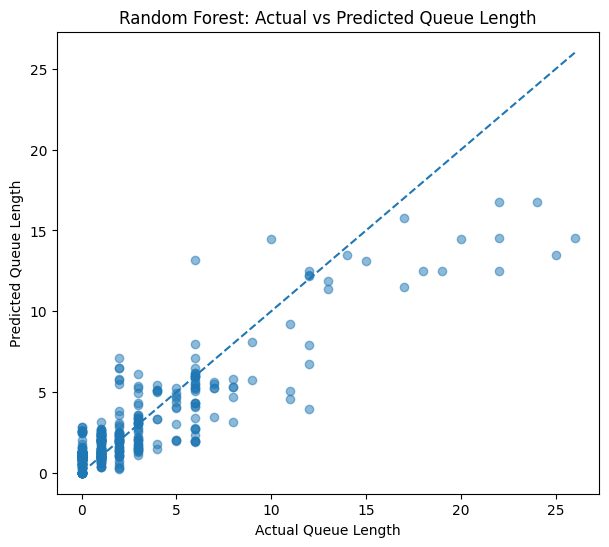

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

# Perfect prediction line
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Actual Queue Length")
plt.ylabel("Predicted Queue Length")
plt.title("Random Forest: Actual vs Predicted Queue Length")
plt.show()

### 🔎 Inference — Actual vs predicted plot
The dashed diagonal represents perfect prediction.

The closer points are to that line, the smaller the prediction error.

This visual is useful because a single metric can hide systematic behavior, such as underprediction at large queue values.

In [81]:
# Check model performance at different queue levels

results_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_rf
})

results_df["absolute_error"] = (
    abs(results_df["actual"] - results_df["predicted"])
)

results_df["queue_group"] = pd.cut(
    results_df["actual"],
    bins=[-1, 2, 5, 10, 100],
    labels=["Low (0-2)", "Medium (3-5)", "High (6-10)", "Very High (11+)"]
)

group_results = results_df.groupby(
    "queue_group",
    observed=True
).agg(
    samples=("actual", "count"),
    MAE=("absolute_error", "mean"),
    actual_mean=("actual", "mean"),
    predicted_mean=("predicted", "mean")
).reset_index()

print(group_results.round(3))

       queue_group  samples    MAE  actual_mean  predicted_mean
0        Low (0-2)      313  0.875        0.668           1.392
1     Medium (3-5)       58  1.126        3.534           3.148
2      High (6-10)       45  2.026        6.556           5.217
3  Very High (11+)       24  4.770       16.333          11.639


### 🔎 Inference — Performance by queue level
The error analysis is especially important for this project because **high queues are operationally important**.

Random Forest MAE by queue group:
- Low (0–2): **0.875**
- Medium (3–5): **1.126**
- High (6–10): **2.026**
- Very High (11+): **4.770**

The error increases as queues become larger, so the model is noticeably less precise in extreme congestion.

**Panel takeaway:** the model is useful for short-term prediction, but very high queue conditions remain its hardest regime.

In [82]:
gb_results = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_gb
})

gb_results["absolute_error"] = (
    abs(gb_results["actual"] - gb_results["predicted"])
)

gb_results["queue_group"] = pd.cut(
    gb_results["actual"],
    bins=[-1, 2, 5, 10, 100],
    labels=["Low (0-2)", "Medium (3-5)", "High (6-10)", "Very High (11+)"]
)

gb_group_results = gb_results.groupby(
    "queue_group",
    observed=True
).agg(
    samples=("actual", "count"),
    MAE=("absolute_error", "mean"),
    actual_mean=("actual", "mean"),
    predicted_mean=("predicted", "mean")
).reset_index()

print(gb_group_results.round(3))

       queue_group  samples    MAE  actual_mean  predicted_mean
0        Low (0-2)      313  0.930        0.668           1.480
1     Medium (3-5)       58  0.896        3.534           3.462
2      High (6-10)       45  1.681        6.556           5.000
3  Very High (11+)       24  6.456       16.333           9.877


### 🔎 Inference — Gradient Boosting by queue level
The same queue-group analysis is repeated for Gradient Boosting so we can compare behavior across traffic regimes rather than relying only on one overall score.

Its very-high queue MAE is **6.456**, which is higher than the Random Forest value of **4.770** in this test analysis.

In [83]:
errors = y_test - y_pred_rf

print("Mean Error:", errors.mean())
print("Median Error:", errors.median())
print("Mean Absolute Error:", abs(errors).mean())

print("\nLargest Underpredictions:")
under = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_rf,
    "error": errors.values
})

print(
    under.sort_values("error", ascending=False)
         .head(10)
         .round(2)
)

Mean Error: -0.07140029305301938
Median Error: -0.3700000000000001
Mean Absolute Error: 1.2380366566893832

Largest Underpredictions:
     actual  predicted  error
387    25.0      13.49  11.51
388    26.0      14.55  11.45
385    22.0      12.48   9.52
331    12.0       3.96   8.04
389    22.0      14.51   7.49
386    24.0      16.77   7.23
382    19.0      12.49   6.51
376    11.0       4.59   6.41
330    11.0       5.03   5.97
383    20.0      14.45   5.55


### 🔎 Inference — Direction of error
The mean error is about **-0.071**, which is close to zero overall, but the largest individual underpredictions occur at high actual queue values.

For example, an actual queue of **25** was predicted as **13.49** in the largest underprediction shown.

**Why this matters for signal control:** underpredicting severe congestion can cause the controller to underestimate future demand, so this is an important limitation to acknowledge rather than hide.

In [84]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective="reg:squarederror"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("----------------")
print(f"MAE  : {xgb_mae:.4f}")
print(f"RMSE : {xgb_rmse:.4f}")
print(f"R²   : {xgb_r2:.4f}")

XGBoost Results
----------------
MAE  : 1.2053
RMSE : 2.1288
R²   : 0.7258


### 🔎 Inference — XGBoost comparison
XGBoost adds another strong nonlinear boosting baseline.

Reported test performance:
- **MAE = 1.2053** — lowest MAE among the five evaluated models
- **RMSE = 2.1288**
- **R² = 0.7258**

This is a useful result to mention to the panel: **Random Forest was not the winner on every metric**. It was selected because it offered the strongest R² and RMSE combination in the reported comparison and matched the deployment design.

In [85]:
xgb_results = pd.DataFrame({
    "actual": y_test.values,
    "predicted": y_pred_xgb
})

xgb_results["absolute_error"] = (
    abs(xgb_results["actual"] - xgb_results["predicted"])
)

xgb_results["queue_group"] = pd.cut(
    xgb_results["actual"],
    bins=[-1, 2, 5, 10, 100],
    labels=["Low (0-2)", "Medium (3-5)", "High (6-10)", "Very High (11+)"]
)

xgb_group_results = xgb_results.groupby(
    "queue_group",
    observed=True
).agg(
    samples=("actual", "count"),
    MAE=("absolute_error", "mean"),
    actual_mean=("actual", "mean"),
    predicted_mean=("predicted", "mean")
).reset_index()

print(xgb_group_results.round(3))

       queue_group  samples    MAE  actual_mean  predicted_mean
0        Low (0-2)      313  0.826        0.668           1.364
1     Medium (3-5)       58  0.924        3.534           3.265
2      High (6-10)       45  1.741        6.556           5.004
3  Very High (11+)       24  5.823       16.333          10.510


### 🔎 Inference — XGBoost across queue levels
The queue-group breakdown confirms that very high queues are challenging for all models.

This reinforces a general conclusion from the experiment: **prediction uncertainty grows in rare, extreme congestion conditions**.

In [86]:
# Final model comparison

final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest",
        "Gradient Boosting",
        "XGBoost"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        tuned_mae,
        gb_mae,
        xgb_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        tuned_rmse,
        gb_rmse,
        xgb_rmse
    ],
    "R2": [
        lr_r2,
        rf_r2,
        tuned_r2,
        gb_r2,
        xgb_r2
    ]
})

print(final_results.round(4))

                 Model     MAE    RMSE      R2
0    Linear Regression  1.5469  2.7201  0.5523
1        Random Forest  1.2380  1.9387  0.7726
2  Tuned Random Forest  1.2490  1.9487  0.7702
3    Gradient Boosting  1.3038  2.2236  0.7008
4              XGBoost  1.2053  2.1288  0.7258


### 🔎 Inference — Final model comparison
The full comparison is:

| Model | MAE | RMSE | R² |
|---|---:|---:|---:|
| Linear Regression | 1.5469 | 2.7201 | 0.5523 |
| Random Forest | 1.2380 | 1.9387 | 0.7726 |
| Tuned Random Forest | 1.2490 | 1.9487 | 0.7702 |
| Gradient Boosting | 1.3038 | 2.2236 | 0.7008 |
| XGBoost | 1.2053 | 2.1288 | 0.7258 |

**Interpretation:** XGBoost has the lowest MAE, while Random Forest has the highest R² and lowest RMSE. The project therefore selects Random Forest as the primary model based on the overall evaluation criteria and deployment fit.

### 15.1 Model Comparison

Five regression models were evaluated using the same temporally held-out test dataset:

- Linear Regression
- Random Forest
- Tuned Random Forest
- Gradient Boosting
- XGBoost

Random Forest achieved the highest R² and lowest RMSE among the evaluated models, while XGBoost achieved the lowest MAE.

Further error analysis showed that all models experienced increased error for very high queue lengths. Random Forest produced the lowest MAE for the Very High (11+) queue group among the evaluated models.

Therefore, Random Forest is selected as the primary traffic-queue prediction model for the proposed system.

### 15.2 Final Model Selection

**Selected Model: Random Forest Regressor**

The Random Forest model is selected based on:

1. Strong overall prediction performance.
2. Highest R² among the evaluated models (0.7726).
3. Lowest RMSE among the evaluated models (1.9387).
4. Better performance on very high queue lengths compared with Gradient Boosting and XGBoost.
5. Ability to capture nonlinear relationships between traffic features.
6. No requirement for feature scaling, making deployment simpler.
7. Good interpretability through feature importance.

The selected model predicts the traffic queue length approximately 30 seconds into the future using current traffic conditions, historical traffic trends, congestion score, and signal state.

### 🔎 Inference — Why Random Forest is the deployed model
The selection is based on:
- highest reported **R² (0.7726)**
- lowest reported **RMSE (1.9387)**
- strong overall MAE (**1.2380**)
- better very-high-queue error than the compared boosting models in the reported analysis
- nonlinear modeling capacity
- no need for scaling
- interpretable feature importance

**Important distinction:** this is a project-level model selection decision, not a claim that Random Forest is universally the best traffic predictor.

In [88]:
# Section 16: Final Model Training

from sklearn.ensemble import RandomForestRegressor

final_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

final_rf.fit(X_train, y_train)

print("Final Random Forest trained successfully!")
print("Training samples:", X_train.shape[0])
print("Number of features:", X_train.shape[1])

Final Random Forest trained successfully!
Training samples: 2040
Number of features: 11


### 🔎 Inference — Final deployment model
The final exported model uses **100 trees**, `random_state=42`, and `n_jobs=-1`.

This intentionally matches the 100-tree Random Forest that produced the reported selected evaluation results.

**Panel takeaway:** the model being deployed is clearly tied to the evaluated configuration, rather than silently replacing it with a different tuned model.

In [ ]:
import joblib

model_path = MODEL_DIR / 'traffic_prediction_rf.pkl'
joblib.dump(final_rf, model_path)

print('Model saved successfully!')
print('Saved to:', model_path)


### 🔎 Inference — Save the model
`joblib.dump()` converts the trained estimator into a reusable file.

This matters for deployment because the SUMO controller does not need to retrain the model; it only needs to load the already-trained artifact and call `predict()`.

In [ ]:
import joblib

feature_info = {
    'features': list(X_train.columns),
    'prediction_target': 'target_queue_30s',
    'prediction_horizon_seconds': 30
}

feature_info_path = MODEL_DIR / 'traffic_prediction_features.pkl'
joblib.dump(feature_info, feature_info_path)

print('Feature information saved successfully!')
print('Saved to:', feature_info_path)


### 🔎 Inference — Save the model contract
The feature metadata records:
- the exact **11 input features**
- target: `target_queue_30s`
- horizon: **30 seconds**

This is effectively the **model contract** between training and deployment: inference code must provide these same features in the same semantic meaning.

In [ ]:
import joblib

saved_model = joblib.load(MODEL_DIR / 'traffic_prediction_rf.pkl')
saved_features = joblib.load(MODEL_DIR / 'traffic_prediction_features.pkl')

print('Saved model loaded successfully! ✅')
print('\nFeatures expected by model:')
print(saved_features['features'])


### 🔎 Inference — Reload test
Reloading the saved model verifies that the exported file can be loaded successfully and that the expected feature metadata is available.

This catches deployment problems before integrating the model into the traffic controller.

In [93]:
# Test saved model on a real test observation

sample = X_test.iloc[[0]]

saved_prediction = saved_model.predict(sample)[0]
actual_value = y_test.iloc[0]

print("Saved Model Test")
print("----------------")
print(f"Predicted queue after 30 seconds: {saved_prediction:.2f}")
print(f"Actual queue after 30 seconds:    {actual_value:.2f}")

Saved Model Test
----------------
Predicted queue after 30 seconds: 1.15
Actual queue after 30 seconds:    1.00


### 🔎 Inference — Real held-out observation
The saved model predicted **1.15 vehicles** for a test observation whose actual 30-second queue was **1.00**.

The absolute error for this example is only **0.15 vehicle**, showing a concrete inference example rather than only aggregate metrics.

In [94]:
# Verify saved model produces the same prediction as the original model

original_prediction = final_rf.predict(sample)[0]
saved_prediction = saved_model.predict(sample)[0]

print("Model Verification")
print("------------------")
print(f"Original model prediction: {original_prediction:.6f}")
print(f"Saved model prediction:    {saved_prediction:.6f}")

print("\nMatch:", np.isclose(original_prediction, saved_prediction))

Model Verification
------------------
Original model prediction: 1.150000
Saved model prediction:    1.150000

Match: True


### 🔎 Inference — Model integrity check
The original and reloaded models produced the same prediction (**1.150000**), and the comparison returned `True`.

**Panel takeaway:** the model exported for deployment is functionally identical to the trained model used before saving.

In [95]:
# Section 18: Manual Traffic-State Prediction

sample_traffic = pd.DataFrame([{
    "vehicles": 12,
    "queue_length": 7,
    "average_speed": 4.5,
    "count_trend": 2,
    "queue_trend": 1,
    "speed_trend": -0.8,
    "avg_count_20s": 10.5,
    "avg_queue_20s": 6.0,
    "avg_speed_20s": 5.2,
    "congestion_score": 0.70,
    "is_green": 1
}])

prediction = saved_model.predict(sample_traffic)[0]

print("Manual Traffic-State Prediction")
print("--------------------------------")
print(f"Current vehicles       : {sample_traffic['vehicles'].iloc[0]}")
print(f"Current queue          : {sample_traffic['queue_length'].iloc[0]}")
print(f"Average speed          : {sample_traffic['average_speed'].iloc[0]}")
print(f"Predicted queue (30s)  : {prediction:.2f}")

Manual Traffic-State Prediction
--------------------------------
Current vehicles       : 12
Current queue          : 7
Average speed          : 4.5
Predicted queue (30s)  : 3.83


### 🔎 Inference — Deployment-style manual input
This cell simulates what the live system will provide after the traffic-perception stage.

The example contains:
- current vehicles = **12**
- current queue = **7**
- average speed = **4.5**
- recent trends and averages
- congestion score = **0.70**
- signal state = green

The model turns this traffic state into a future queue estimate.

In [96]:
# Convert predicted queue into congestion level

predicted_queue = prediction

if predicted_queue <= 2:
    predicted_congestion = "LOW"
elif predicted_queue <= 5:
    predicted_congestion = "MEDIUM"
else:
    predicted_congestion = "HIGH"

print("Prediction Result")
print("-----------------")
print(f"Predicted queue: {predicted_queue:.2f}")
print(f"Predicted congestion: {predicted_congestion}")

Prediction Result
-----------------
Predicted queue: 3.83
Predicted congestion: MEDIUM


### 🔎 Inference — Convert regression output into an interpretable state
The numeric prediction is translated into a simple operational label:

- ≤ 2 → LOW
- 3–5 → MEDIUM
- > 5 → HIGH

For the example, the predicted queue is **3.83**, giving **MEDIUM** predicted congestion.

This is not a second ML model; it is a rule-based interpretation layer on top of the regression output.

In [97]:
# Compare current and predicted queue

current_queue = sample_traffic["queue_length"].iloc[0]
predicted_queue = prediction

queue_change = predicted_queue - current_queue

print("Traffic Prediction Trend")
print("------------------------")
print(f"Current queue:          {current_queue:.2f}")
print(f"Predicted queue (30s):  {predicted_queue:.2f}")
print(f"Expected change:        {queue_change:+.2f}")

if queue_change > 1:
    trend = "INCREASING"
elif queue_change < -1:
    trend = "DECREASING"
else:
    trend = "STABLE"

print(f"Traffic trend:          {trend}")

Traffic Prediction Trend
------------------------
Current queue:          7.00
Predicted queue (30s):  3.83
Expected change:        -3.17
Traffic trend:          DECREASING


### 🔎 Inference — Current vs future traffic
The example moves from current state to expected future state:

**Current queue = 7 → Predicted queue = 3.83**

Expected change = **−3.17 vehicles**, so the inferred trend is **DECREASING**.

This is exactly the kind of information the downstream signal controller can consume: not just “what is traffic now?”, but “what is likely to happen next?”

In [98]:
def predict_traffic_state(traffic_features):
    """
    Predict queue length 30 seconds into the future
    and determine the expected traffic trend.
    """

    input_data = pd.DataFrame([traffic_features])

    predicted_queue = saved_model.predict(input_data)[0]

    current_queue = traffic_features["queue_length"]
    queue_change = predicted_queue - current_queue

    if predicted_queue <= 2:
        congestion = "LOW"
    elif predicted_queue <= 5:
        congestion = "MEDIUM"
    else:
        congestion = "HIGH"

    if queue_change > 1:
        trend = "INCREASING"
    elif queue_change < -1:
        trend = "DECREASING"
    else:
        trend = "STABLE"

    return {
        "predicted_queue_30s": predicted_queue,
        "congestion": congestion,
        "queue_change": queue_change,
        "trend": trend
    }


# Test the function using our previous traffic state

result = predict_traffic_state({
    "vehicles": 12,
    "queue_length": 7,
    "average_speed": 4.5,
    "count_trend": 2,
    "queue_trend": 1,
    "speed_trend": -0.8,
    "avg_count_20s": 10.5,
    "avg_queue_20s": 6.0,
    "avg_speed_20s": 5.2,
    "congestion_score": 0.70,
    "is_green": 1
})

print(result)

{'predicted_queue_30s': np.float64(3.83), 'congestion': 'MEDIUM', 'queue_change': np.float64(-3.17), 'trend': 'DECREASING'}


### 🔎 Inference — Deployment function
`predict_traffic_state()` wraps the trained model into a reusable inference function.

Its output contains:
- predicted queue in 30 seconds
- predicted congestion level
- expected queue change
- traffic trend

This is the bridge from a research notebook to an application/service API.

## 🎯 Panel-ready model summary

### What goes into the model
**11 features:** current traffic + short-term trends + 20-second rolling averages + congestion score + signal state.

### What comes out
**Predicted queue length ~30 seconds ahead.**

### Why Random Forest?
In the reported comparison, Random Forest had:
- **R² = 0.7726** — highest among the five evaluated models
- **RMSE = 1.9387** — lowest among the five
- **MAE = 1.2380**
- strong behavior on the very-high queue group relative to the compared tree models

### What the model is NOT claiming
The notebook demonstrates short-term predictive performance on the project's scenario data. It does **not** by itself prove performance on every real-world road, camera setup, weather condition, or traffic network.

### How it connects to the traffic controller
```text
Camera / SUMO state
       ↓
Vehicles + queue + speed
       ↓
History + trends + congestion
       ↓
Random Forest
       ↓
Predicted queue after ~30 s
       ↓
AI signal controller
```


## 🚦 Final demo cell — one screen for the panel

Use this as the final notebook cell during the presentation. It gives the panel a compact summary of what the ML component actually does.

In [ ]:
# Compact panel summary using the already-computed notebook results

panel_summary = pd.DataFrame({
    "Item": [
        "Task",
        "Prediction horizon",
        "Training rows",
        "Test rows",
        "Feature count",
        "Selected model",
        "Random Forest MAE",
        "Random Forest RMSE",
        "Random Forest R²"
    ],
    "Value": [
        "Traffic queue regression",
        "30 seconds",
        len(X_train),
        len(X_test),
        len(feature_columns),
        "Random Forest (100 trees)",
        f"{rf_mae:.4f}",
        f"{rf_rmse:.4f}",
        f"{rf_r2:.4f}"
    ]
})

display(panel_summary)

print("\nKEY MESSAGE:")
print("Current traffic state + recent history -> future queue prediction -> signal-control input")
